In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [41]:
df= pd.read_csv("tumor.csv")

In [42]:
df.sample(5)

,radius,texture,area,diagnosis
201,13.78,13.31,584.50,0
187,27.60,29.40,1435.03,1
104,16.21,39.04,1122.76,1
270,19.95,31.95,1230.82,1
334,17.01,23.62,1947.12,1


In [43]:
X= df.drop('diagnosis', axis=1)
y= df['diagnosis']

# Train test split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)           

# Applying PCA

In [45]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)    

In [46]:
model= LogisticRegression()
model.fit(X_train_pca, y_train)
y_pred= model.predict(X_test_pca)
print(y_pred)

[1 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0
 0 1 0 1 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1]


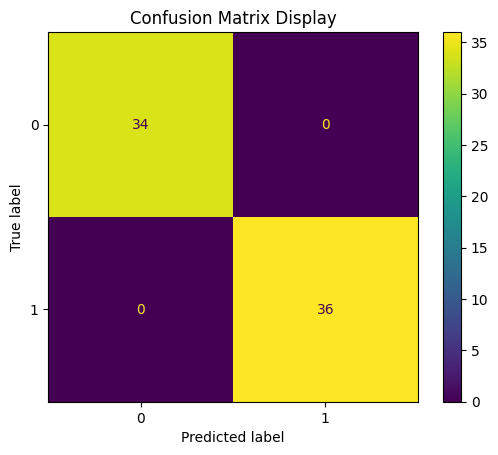

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix Display")
plt.show()

In [48]:
print("Classification Report:\n\n", classification_report(y_test, y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        36

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [49]:
print("Variance explained:", pca.explained_variance_ratio_)
print("Total:", sum(pca.explained_variance_ratio_) * 100, "%")

Variance explained: [0.80388779 0.11027328]
Total: 91.41610784365713 %


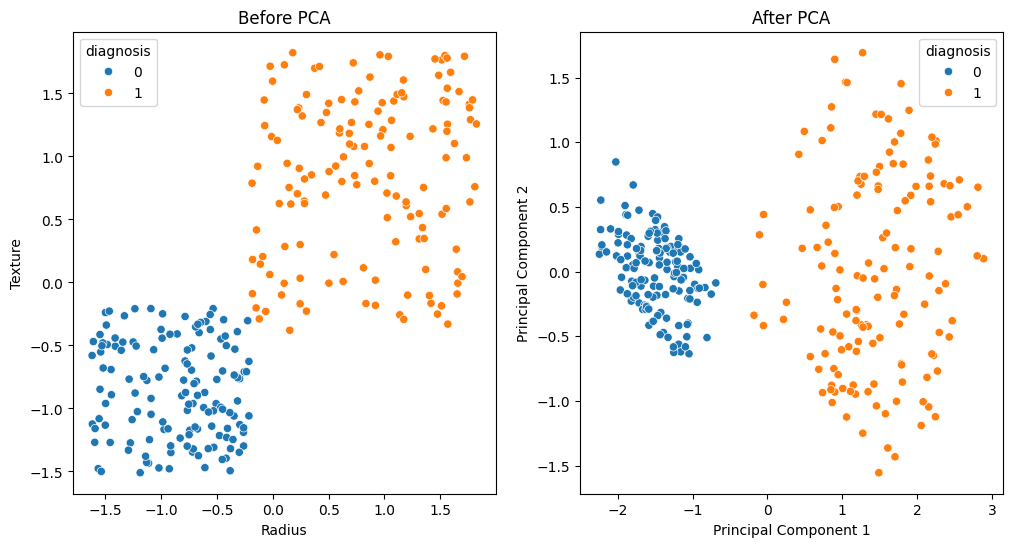

In [50]:
fig, ax= plt.subplots(1,2, figsize=(12,6))
sns.scatterplot(x=X_train_scaled[:,0], y=X_train_scaled[:,1], hue= y_train, ax=ax[0])
ax[0].set_xlabel("Radius")
ax[0].set_ylabel("Texture")
ax[0].set_title("Before PCA")

sns.scatterplot(x= X_train_pca[:,0], y= X_train_pca[:,1], hue= y_train, ax=ax[1])
ax[1].set_xlabel("Principal Component 1")
ax[1].set_ylabel("Principal Component 2")
ax[1].set_title("After PCA")
plt.show()